In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import matplotlib.cm as cm
import matplotlib.colors as colors
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from matplotlib.lines import Line2D
import matplotlib as mpl
import warnings; warnings.simplefilter('ignore')
import os
import sys
import h5py
import pandas as pd
import seaborn as sns
sys.path.insert(0, '/Users/jsmonzon/Research/SatGen/mcmc/src/')
import jsm_ancillary
import jsm_visualize
import jsm_SHMR
import jsm_mcmc
import jsm_stats
import jsm_simload
import evolve as ev
import galhalo as gh
import profiles as profiles
import config as cfg

In [3]:
plt.style.use('../../../SatGen/notebooks/paper1/paper.mplstyle')
double_textwidth = 7.0 #inches
single_textwidth = 3.5 #inches
levelz = [1-0.99, 1-0.95, 1-0.68]

In [5]:
art_kall = jsm_ancillary.load_massspec_timeseries("../../data/vdb/500_particles/", "artificial")

split_kall = jsm_ancillary.split_mass_spec(art_kall)

In [8]:
art_k1 = jsm_ancillary.load_massspec_timeseries("../../data/vdb/500_particles/", "artificial", order="k1")

split_k1 = jsm_ancillary.split_mass_spec(art_k1)

In [9]:
art_k2 = jsm_ancillary.load_massspec_timeseries("../../data/vdb/500_particles/", "artificial", order="k2")

split_k2 = jsm_ancillary.split_mass_spec(art_k2)

In [10]:
art_k3 = jsm_ancillary.load_massspec_timeseries("../../data/vdb/500_particles/", "artificial", order="k3")

split_k3 = jsm_ancillary.split_mass_spec(art_k3)

In [11]:
Nmean_kall = []

for df in split_kall:

    df_res = jsm_ancillary.compute_mass_bin_stats(df, "fsub")

    Nmean_kall.append(df_res["mean"])

In [12]:
Nmean_k1 = []

for df in split_k1:

    df_res = jsm_ancillary.compute_mass_bin_stats(df, "fsub")

    Nmean_k1.append(df_res["mean"])

In [13]:
Nmean_k1 = []

for df in split_k1:

    df_res = jsm_ancillary.compute_mass_bin_stats(df, "fsub")

    Nmean_k1.append(df_res["mean"])

In [14]:
Nmean_k2 = []

for df in split_k2:

    df_res = jsm_ancillary.compute_mass_bin_stats(df, "fsub")

    Nmean_k2.append(df_res["mean"])

In [15]:
Nmean_k3 = []

for df in split_k3:

    df_res = jsm_ancillary.compute_mass_bin_stats(df, "fsub")

    Nmean_k3.append(df_res["mean"])

In [16]:
# np.unique(art_kall["logMvir"])

mvir_label = np.array([12.6, 12.8, 13. , 13.2, 13.4, 13.6, 13.8, 14. ])

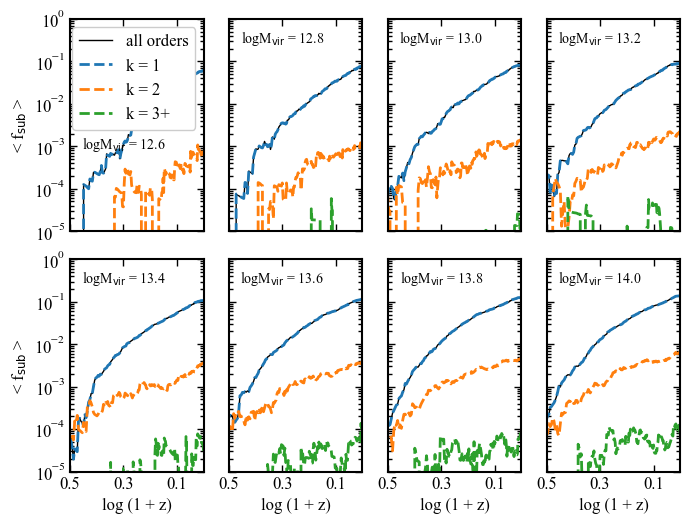

In [24]:
fig, axes = plt.subplots(2, 4, sharex=True, sharey=True,
                              figsize=(double_textwidth, 1.5*single_textwidth))

axes = axes.flatten()

for i in range(8):
    
    ax = axes[i]

    ax.plot(np.log10(1 + cfg.zsample), Nmean_kall[i], lw=1, color="k", label="all orders")
    ax.plot(np.log10(1 + cfg.zsample), Nmean_k1[i], lw=2, ls="--", label="k = 1")
    ax.plot(np.log10(1 + cfg.zsample), Nmean_k2[i], lw=2, ls="--", label="k = 2")
    ax.plot(np.log10(1 + cfg.zsample), Nmean_k3[i], lw=2, ls="--", label="k = 3+")

    ax.set_yscale("log")
    ax.set_ylim(1e-5, 1)
    ax.set_xlim(0.5, 0.0)
    ax.set_xticks([0.5, 0.3, 0.1])

    if i==0:
        ax.text(0.4, 0.45, f"logM$_{{\\rm vir}}$ = {mvir_label[i]:.1f}",
            transform=ax.transAxes, ha="center", va="top", fontsize=10)
    else:
        ax.text(0.4, 0.95, f"logM$_{{\\rm vir}}$ = {mvir_label[i]:.1f}",
            transform=ax.transAxes, ha="center", va="top", fontsize=10)

for ax in axes[-4:]:
    ax.set_xlabel("log (1 + z)")
for ax in axes[::4]:
    ax.set_ylabel("< f$_{\\rm sub}$ >")

axes[0].legend(framealpha=1)

plt.tight_layout()
# plt.savefig("../../figures/paper/Nacc_orders.pdf", bbox_inches="tight")
plt.show()


In [32]:
def MAH_split_grid(split_list, key, arr_label, splitsize=200):
    """
    Plots one panel per mass bin in a 2x4 grid, ordered from least massive
    (top-left) to most massive (bottom-right). Each panel reproduces the
    single-panel MAH_split logic: chunks of `splitsize` trees, sorted by
    `arr_label`'s underlying array (log1pz50), averaged and colored by
    that chunk's median value.

    split_list : list of per-mass-bin DataFrames (e.g. from split_mass_spec)
    key        : column name to plot (e.g. "Nsub")
    arr_label  : colorbar label (e.g. "log (1+z$_{50}$)")
    """
    split_sorted = sorted(split_list, key=lambda df: np.median(df["logMvir"]))

    n_bins = len(split_sorted)
    ncols = 4
    nrows = int(np.ceil(n_bins / ncols))

    norm = mpl.colors.Normalize(vmin=0.1, vmax=0.45)
    cmap = mpl.cm.coolwarm
    sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])

    xvals = np.log10(1 + cfg.zsample)

    fig, axes = plt.subplots(nrows, ncols, sharex=True, sharey=True,
                              figsize=(double_textwidth, 1.5*single_textwidth))
    axes = axes.flatten()

    for panel_i, subsample in enumerate(split_sorted):
        ax = axes[panel_i]

        mat = jsm_ancillary.stack_series(subsample, key)   # (Ntrees, Ntime)
        sort_arr = subsample["log1pz50"].values            # (Ntrees,)

        sort_mask = sort_arr.argsort()
        arr_sorted = sort_arr[sort_mask]
        mat_sorted = mat[sort_mask]

        num_chunks = mat.shape[0] // splitsize

        for i in range(num_chunks):
            idx_start = i * splitsize
            idx_end = (i + 1) * splitsize

            chunk_med = np.average(arr_sorted[idx_start:idx_end])
            color = cmap(norm(chunk_med))

            average_chunk = np.average(mat_sorted[idx_start:idx_end], axis=0)
            ax.plot(xvals, average_chunk, color=color, lw=1.5)

        ax.set_yscale("log")
        ax.set_ylim(1e-5, 1)
        ax.set_xlim(0.5, 0.0)
        ax.set_xticks([0.5, 0.3, 0.1])

        mvir_label = np.median(subsample["logMvir"])
        ax.text(0.4, 0.95, f"logM$_{{\\rm vir}}$ = {mvir_label:.1f}",
                transform=ax.transAxes, ha="center", va="top", fontsize=10)

    for j in range(n_bins, len(axes)):
        axes[j].axis("off")

    for ax in axes[-ncols:]:
        ax.set_xlabel("log (1 + z)")
    for ax in axes[::ncols]:
        ax.set_ylabel("< f$_{\\rm sub}$ >")

    # shared colorbar — reserve space via subplots_adjust, no tight_layout
    fig.subplots_adjust(top=0.82, bottom=0.1, left=0.08, right=0.98, hspace=0.15, wspace=0.1)
    cbar_ax = fig.add_axes([0.25, 0.92, 0.5, 0.02])
    cbar = fig.colorbar(sm, cax=cbar_ax, orientation='horizontal')
    cbar.set_label(arr_label, loc="center")

    # plt.savefig("../../figures/paper/Nacc_z50.pdf", bbox_inches="tight")
    plt.show()


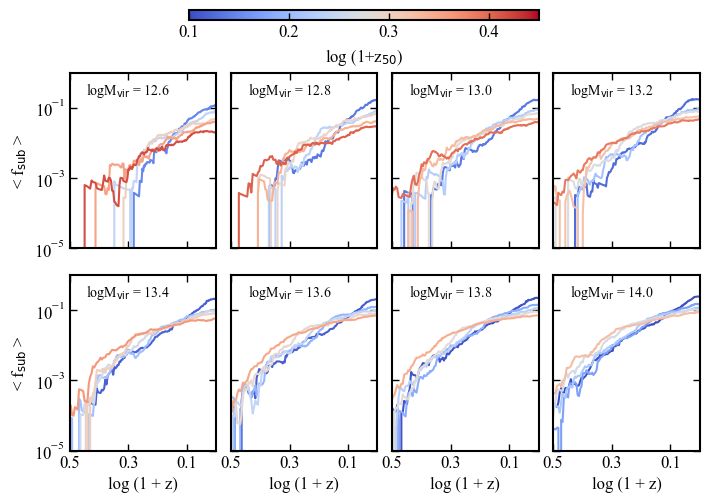

In [33]:
MAH_split_grid(split_k1, "fsub", "log (1+z$_{50}$)")

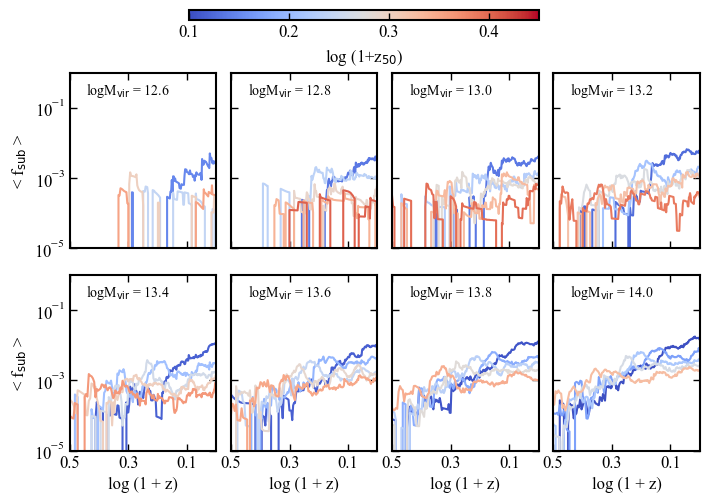

In [34]:
MAH_split_grid(split_k2, "fsub", "log (1+z$_{50}$)")